Auteurs: Matis Braun et Virgile Hermant

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

import torch
from matplotlib.animation import FuncAnimation
from collections import defaultdict
import datetime
from math import inf

# Classe Tensor

In [2]:
class Tensor:
    """ stores a single scalar Tensor and its gradient """

    def __init__(self, data, _children=(), _op=''):

        self.data = data
        self.grad = 0.0

        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op  # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)

        out = Tensor(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        out._prev = {self, other}
        return out

    def __mul__(self, other):

        other = other if isinstance(other, Tensor) else Tensor(other)

        out = Tensor(self.data * other.data, [self, other], '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __pow__(self, other):

        assert isinstance(other, (int, float)), "only supporting int/float powers for now"

        out = Tensor(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad

        out._backward = _backward

        return out

    def relu(self):
        out = Tensor(max(0, self.data), (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backward

        return out

    def build_topo(self, visited=None, topo=None):
        if self not in visited:
            visited.add(self)
            for child in self._prev:
                child.build_topo(visited=visited, topo=topo)
            topo.append(self)
        return topo

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        topo = self.build_topo(topo=topo, visited=visited)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __neg__(self):  # -self
        return self * -1

    def __radd__(self, other):  # other + self
        return self + other

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __rsub__(self, other):  # other - self
        return other + (-self)

    def __rmul__(self, other):  # other * self
        return self * other

    def __truediv__(self, other):  # self / other
        return self * other ** -1

    def __rtruediv__(self, other):  # other / self
        return other * self ** -1

    def __repr__(self):
        return f"Tensor(data={self.data}, grad={self.grad})"

In [3]:
def cos_d(dual_number: Tensor):
    out = Tensor(np.cos(dual_number.data), (dual_number,), 'cos')

    def _backward():
        dual_number.grad += -np.sin(dual_number.data) * out.grad

    out._backward = _backward
    return out

In [4]:
def sigmoid_d(dual_number: Tensor):
    sig = 1 / (1 + np.exp(-dual_number.data))
    out = Tensor(sig, (dual_number,), 'sigmoid')

    def _backward():
        dual_number.grad += sig * (1 - sig) * out.grad

    out._backward = _backward
    return out

In [26]:
def ReLU(dual_number: Tensor):
    out = Tensor(0 if self.data < 0 else self.data, [self], 'ReLU')

    def _backward():
        self.grad += (self.data > 0) * out.grad

    out._backward = _backward
    return out

# Génération des données

In [5]:
 # Génération du jeu de données linéaire

np.random.seed(0)
n_samples = 100
x_linear = np.linspace(-10, 10, n_samples)
y_linear = 3 * x_linear + 5 + np.random.normal(0, 2,
                                               n_samples)

In [6]:
# Génération du jeu de données non linéaire
y_nonlinear = 0.5 * x_linear ** 2 - 4 * x_linear + np.random.normal(0, 5, n_samples)


# Optimizer

In [7]:
class Optimizer:
    def __init__(self, params, defaults):
        self.params = params
        self.defaults = defaults

    def step(self):
        pass

    def zero_grad(self):
        for param_id in self.params:
            param = self.params[param_id]
            param.grad = 0.0

##  Stochastic Gradient Descent (SGD)

SGD est une méthode d’optimisation qui met à jour les paramètres du modèle en
fonction du gradient de la fonction de perte par rapport aux paramètres. Cette
méthode est simple et efficace pour de nombreux problèmes d’optimisation.

**Formule**:
$$\theta_{t+1} = \theta_{t} - \eta \nabla_{\theta}L(\theta_{t})$$

In [8]:
class SGD(Optimizer):
    def __init__(self, params, learning_rate=0.01):
        if not 0.0 < learning_rate < 1.0:
            raise ValueError("Invalid learning rate: {}".format(learning_rate))
        defaults = dict(lr=learning_rate)
        params = {param_id: param for param_id, param in zip(range(len(params)), params)}
        super(SGD, self).__init__(params, defaults)

    def step(self):
        for param_id in self.params:
            param = self.params[param_id]
            if param.grad is not None:
                param.data = param.data - self.defaults["lr"] * param.grad

## RMSProp

RMSProp adapte le taux d’apprentissage pour chaque paramètre en fonction de
la moyenne des carrés des gradients passés. Cela aide à stabiliser les mises à
jour des paramètres en réduisant l’impact des grands gradients.

**Formule**:
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{ E[g^{2}]_{t} + \epsilon }} \nabla_{\theta}L(\theta_{t})$$

In [9]:
class RMSProp(Optimizer):
    def __init__(self, params, learning_rate=0.01, decay=0.9):
        if not 0.0 < learning_rate < 1.0:
            raise ValueError("Invalid learning rate: {}".format(learning_rate))
        defaults = dict(lr=learning_rate, decay=decay, epsilon=1e-8)
        params = {param_id: param for param_id, param in zip(range(len(params)), params)}
        super(RMSProp, self).__init__(params, defaults)

        self.state = {param_id: {"e": 0.0} for param_id in range(len(params))}

    def step(self):
        decay = self.defaults["decay"]
        lr = self.defaults["lr"]
        epsilon = self.defaults["epsilon"]

        for param_id in self.params:
            param = self.params[param_id]
            if param.grad is None:
                continue

            state = self.state[param_id]
            e = state["e"]
            e = decay * e + (1 - decay) * (param.grad ** 2)

            param.data -= lr * param.grad / sqrt(e + epsilon)

            state["e"] = e

## Adagrad

Adagrad ajuste le taux d’apprentissage pour chaque paramètre en fonction
des gradients passés, favorisant des mises à jour plus importantes pour les
paramètres moins fréquemment mis à jour.


**Formule**:
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{ G_{t}+ \epsilon }} \nabla_{\theta}L(\theta_{t})$$

In [10]:
class Adagrad(Optimizer):
    def __init__(self, params, learning_rate=0.01):
        if not 0.0 < learning_rate < 1.0:
            raise ValueError("Invalid learning rate: {}".format(learning_rate))
        defaults = dict(lr=learning_rate, epsilon=1e-8)
        params = {param_id: param for param_id, param in zip(range(len(params)), params)}
        super(Adagrad, self).__init__(params, defaults)
        self.state = {param_id: {"g": 0.0} for param_id in range(len(params))}

    def step(self):
        lr = self.defaults["lr"]
        epsilon = self.defaults["epsilon"]

        for param_id in self.params:
            param = self.params[param_id]
            if param.grad is None:
                continue

            state = self.state[param_id]
            g = state["g"]
            g += param.grad ** 2

            param.data -= (lr / sqrt(g + epsilon)) * param.grad

            self.state[param_id]["g"] = g

## Adam

Adam combine les avantages de RMSProp et de Momentum en utilisant des
moments exponentiels pour estimer les premiers et seconds moments des gradients

**Formules**:
$$
\begin{equation}
\begin{split}
m_{t} &= \beta_{1}m_{t} + (1 - \beta_{1}) \nabla_{\theta} L(\theta_{t}) \\
v_{t} &= \beta_{2}v_{t-1} + (1 - \beta_{2})(\nabla_{\theta}L(\theta_{t}))^2 \\
\theta_{t+1} &= \theta_{t} - \frac{\eta}{\sqrt{ \hat{v}_{t} }+ \epsilon} \hat{m}_{t}
\end{split}
\end{equation}
$$

In [11]:
class Adam(Optimizer):
    def __init__(self, params, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        if not 0.0 < learning_rate < 1.0:
            raise ValueError("Invalid learning rate: {}".format(learning_rate))
        defaults = dict(lr=learning_rate, beta1=beta1, beta2=beta2, epsilon=eps)
        params = {param_id: param for param_id, param in zip(range(len(params)), params)}
        super(Adam, self).__init__(params, defaults)
        self.state = {param_id: {"m": 0.0, "v": 0.0} for param_id in range(len(params))}

    def step(self):
        lr = self.defaults["lr"]
        beta1 = self.defaults["beta1"]
        beta2 = self.defaults["beta2"]
        epsilon = self.defaults["epsilon"]

        for param_id in self.params:
            param = self.params[param_id]
            if param.grad is None:
                continue

            state = self.state[param_id]
            m, v = state["m"], state["v"]

            m = beta1 * m + (1 - beta1) * param.grad
            v = beta2 * v + (1 - beta2) * (param.grad ** 2)

            mhat = m / (1 - beta1)
            vhat = v / (1 - beta2)

            param.data -= mhat * (lr / (sqrt(vhat) + epsilon))

            self.state[param_id]["m"] = m
            self.state[param_id]["v"] = v

## AdamW

AdamW est une variante d’Adam qui ajoute une régularisation L2 pour améliorer
la généralisation.

**Formule**:
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{ \hat{v}_{t}}+ \epsilon}\hat{m}_{t}-\eta\lambda\theta_{t}$$

In [12]:
class AdamW(Optimizer):
    def __init__(self, params, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        if not 0.0 < learning_rate < 1.0:
            raise ValueError("Invalid learning rate: {}".format(learning_rate))
        defaults = dict(lr=learning_rate, beta1=beta1, beta2=beta2, epsilon=eps, decay=weight_decay)
        params = {param_id: param for param_id, param in zip(range(len(params)), params)}
        super(AdamW, self).__init__(params, defaults)
        self.state = {param_id: {"m": 0.0, "v": 0.0} for param_id in range(len(params))}

    def step(self):
        lr = self.defaults["lr"]
        beta1 = self.defaults["beta1"]
        beta2 = self.defaults["beta2"]
        epsilon = self.defaults["epsilon"]
        decay = self.defaults["decay"]

        for param_id in self.params:
            param = self.params[param_id]
            if param.grad is None:
                continue

            state = self.state[param_id]
            m, v = state["m"], state["v"]

            m = beta1 * m + (1 - beta1) * param.grad
            v = beta2 * v + (1 - beta2) * (param.grad ** 2)

            mhat = m / (1 - beta1)
            vhat = v / (1 - beta2)

            old_data = param.data
            param.data -= (lr / (sqrt(vhat) + epsilon)) * mhat
            param.data -= (lr * decay * old_data)

            self.state[param_id]["m"] = m
            self.state[param_id]["v"] = v

# Evaluation des Optimiseurs

##  Fonctions de Perte

Les fonctions de perte incluent une fonction convexe $(x − 2)^2$
et une fonction
non convexe $3x^2 − 2x$.

In [13]:
def f(x):
    return (x - 2) ** 2


def f_nonconvexe(x):
    return 3 * x ** 2 - 2 * x

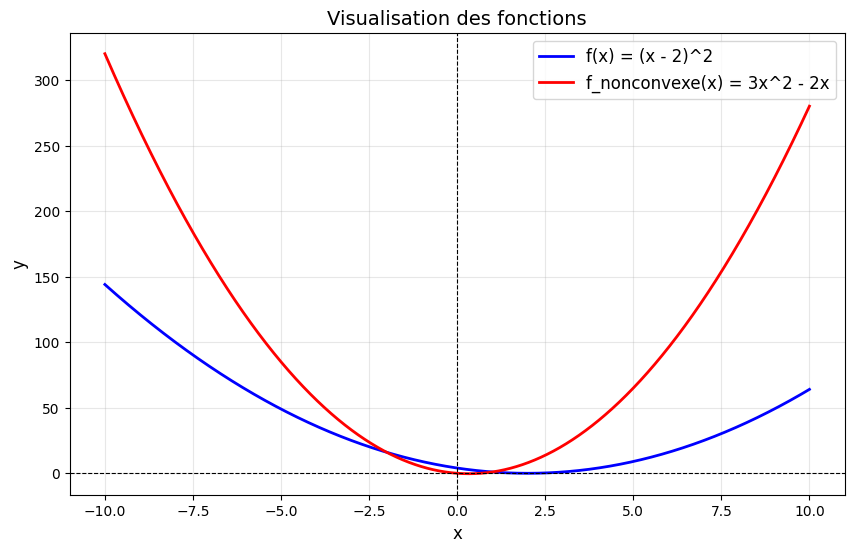

In [14]:
x = np.linspace(-10, 10, 50000)

y1 = f(x)
y2 = f_nonconvexe(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label="f(x) = (x - 2)^2", color="blue", linewidth=2)
plt.plot(x, y2, label="f_nonconvexe(x) = 3x^2 - 2x", color="red", linewidth=2)
plt.title("Visualisation des fonctions", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Expérimentation

L’évaluation des optimiseurs est réalisée en minimisant ces fonctions de perte.
Les résultats sont imprimés à chaque itération pour comparer les performances
des différents algorithmes.

In [15]:
def eval_fn(function, starting_point=4):
    sgd_tensor = Tensor(starting_point)
    sgd = SGD([sgd_tensor], learning_rate=0.001)

    rmsprop_tensor = Tensor(starting_point)
    rmsprop = RMSProp([rmsprop_tensor], learning_rate=0.1)

    adagrad_tensor = Tensor(starting_point)
    adagrad = Adagrad([adagrad_tensor], learning_rate=0.1)

    adam_tensor = Tensor(starting_point)
    adam = Adam([adam_tensor], learning_rate=0.1)

    adamw_tensor = Tensor(starting_point)
    adamw = AdamW([adamw_tensor], learning_rate=0.1)

    tensors = [sgd_tensor, rmsprop_tensor, adagrad_tensor, adam_tensor, adamw_tensor]
    optims = [sgd, rmsprop, adagrad, adam, adamw]

    traj = defaultdict(list)
    for step in range(500):
        for i, (optim, tensor) in enumerate(zip(optims, tensors)):
            loss_sgd = function(tensor)
            optim.zero_grad()
            loss_sgd.backward()
            optim.step()
            traj[i].append(tensor.data)
        print(f"step {step}:")
        for i in range(len(optims)):
            optim = optims[i]
            t = traj[i]
            print(f"    - {optim.__class__.__name__}:{f(t[-1]):.5f}")
    return traj, optims


def create_anim(fn, name, starting_point=4):
    fn_def = '(x - 2)^2' if fn is f else '3x^2 - 2x'
    print(f"=== EVALUATING FUNCTION: {fn_def} ===")
    traj, optims = eval_fn(fn, starting_point=starting_point)
    # Animation
    fig, ax = plt.subplots(figsize=(8, 6))
    x_vals = np.linspace(min(-2, starting_point - 2), max(starting_point + 2, 6), 500)
    y_vals = [(Tensor(x).data, fn(Tensor(x)).data) for x in x_vals]
    x_vals, y_vals = zip(*y_vals)

    ax.plot(x_vals, y_vals, label=f"f(x) = {fn_def}", color="blue", linewidth=2)
    points = []
    for optim, color in zip(optims, ['ro', 'bo', 'go', 'co', 'mo']):
        p, = ax.plot([], [], color, label=optim.__class__.__name__, markersize=8)
        points.append(p)

    ax.set_xlim(np.min(x_vals) - 1, np.max(x_vals) + 1)
    ax.set_ylim(np.min(y_vals) - 5, np.max(y_vals) + 1)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    title = ax.set_title(f"{fn_def} with x_start={starting_point}", fontsize=14)

    def update(frame):
        for i in range(len(points)):
            p = points[i]
            p.set_data([traj[i][frame]], [fn(Tensor(traj[i][frame])).data])
        title.set_text(f"Step: {frame}")
        return *points, title

    ani = FuncAnimation(fig, update, frames=500, interval=200, blit=True)
    ani.save(name)

    # Courbe
    plt.figure()
    x = np.linspace(0, 500, 500)

    plt.plot(x, [fn(traj[0][i]) for i in range(len(traj[0]))], "r-", label="SGD")
    plt.plot(x, [fn(traj[1][i]) for i in range(len(traj[1]))], "g-", label="RMSProp")
    plt.plot(x, [fn(traj[2][i]) for i in range(len(traj[2]))], "b-", label="Adagrad")
    plt.plot(x, [fn(traj[3][i]) for i in range(len(traj[3]))], "c-", label="Adam")
    plt.plot(x, [fn(traj[4][i]) for i in range(len(traj[4]))], "m-", label="AdamW")

    plt.xlabel("number or step")
    plt.ylabel("Function value")
    plt.title(f"Evolutions of all optimizers with function {fn_def} and x_start={starting_point}")
    plt.legend(fontsize=12)
    plt.savefig(name.split(".")[0] + ".png")


def eval_optim(starting_point=4):
    datanow = datetime.datetime.now().strftime('%y-%m-%d_%H-%M-%S')
    create_anim(f, f"convexe_{starting_point}.gif", starting_point=starting_point)
    create_anim(f_nonconvexe, f"nonconvexe_{starting_point}.gif", starting_point=starting_point)


=== EVALUATING FUNCTION: (x - 2)^2 ===
step 0:
    - SGD:254.97702
    - RMSProp:245.98071
    - Adagrad:252.81000
    - Adam:252.81000
    - AdamW:252.23792
step 1:
    - SGD:253.95814
    - RMSProp:238.90457
    - Adagrad:250.57343
    - Adam:248.55536
    - AdamW:247.42538
step 2:
    - SGD:252.94332
    - RMSProp:233.09271
    - Adagrad:248.75814
    - Adam:243.64656
    - AdamW:241.97630
step 3:
    - SGD:251.93256
    - RMSProp:228.01582
    - Adagrad:247.19369
    - Adam:238.31010
    - AdamW:236.11930
step 4:
    - SGD:250.92584
    - RMSProp:223.42920
    - Adagrad:245.80029
    - Adam:232.69470
    - AdamW:230.00433
step 5:
    - SGD:249.92314
    - RMSProp:219.19684
    - Adagrad:244.53310
    - Adam:226.90582
    - AdamW:223.73761
step 6:
    - SGD:248.92444
    - RMSProp:215.23436
    - Adagrad:243.36396
    - Adam:221.02144
    - AdamW:217.39747
step 7:
    - SGD:247.92974
    - RMSProp:211.48532
    - Adagrad:242.27383
    - Adam:215.10060
    - AdamW:211.04306
step 8:
 

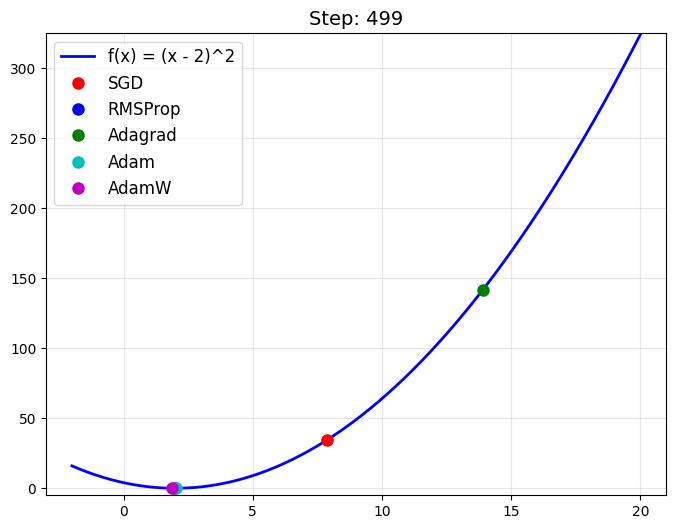

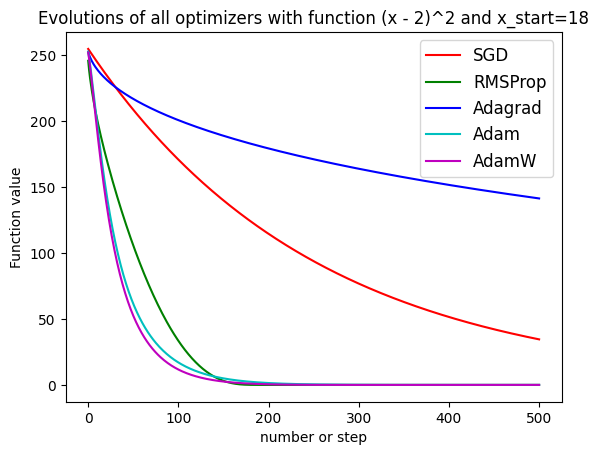

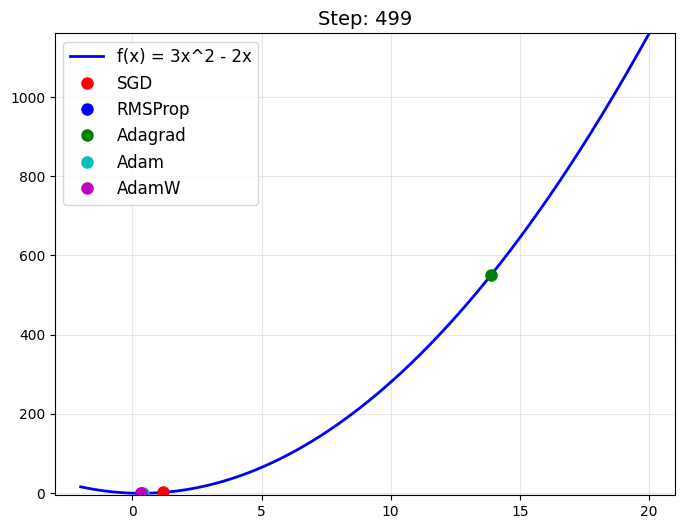

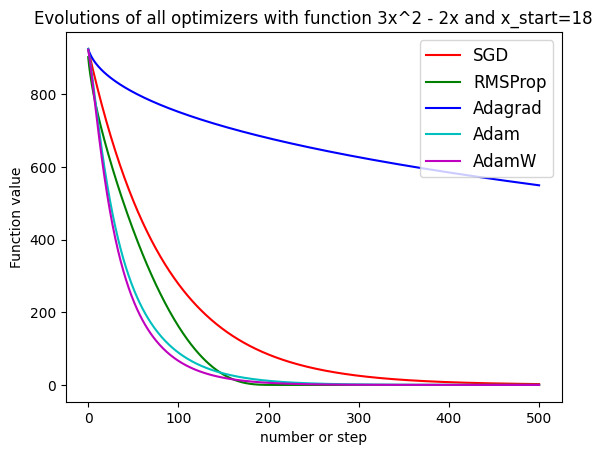

In [222]:
eval_optim(18)


Voici une animation qui montre la minimisation de la fonction convexe par nos différents optimiseurs:
![gif](convexe_18.gif "gif")

Et la même avec la fonction "non convexe":
![gif](nonconvexe_18.gif "gif")

# Réseau de Neurones

## Définition du Modèle

Un réseau de neurones simple avec une couche cachée est défini, ainsi que la
fonction de perte MSE (Mean Squared Error).



In [16]:
import math

def func_nn(x, W1, b1, W2, b2):
    h1 = W1 * x + b1
    y = W2 * h1 + b2
    #y = 1 / (1 + math.exp(-y.))
    y = sigmoid_d(y)
    return y


def mse(y, y_hat):
    return (y - y_hat) ** 2

## Entraînement du Réseau

L’entraînement du réseau de neurones est effectué en utilisant des données
générées, et les performances sont évaluées pour différents optimiseurs.

In [17]:
def create_params(optim_class, **kwargs):
    W1 = Tensor(np.random.randn())
    b1 = Tensor(np.random.randn())
    W2 = Tensor(np.random.randn())
    b2 = Tensor(np.random.randn())

    optim = optim_class([W1, b1, W2, b2], **kwargs)
    return (W1, b1, W2, b2), optim


In [18]:
import math
def eval_nn_optim(x_data, y_data, optimizer, params, epochs):
    W1, b1, W2, b2 = params
    losses = []
    for epoch in range(epochs):
        epoch_loss = []
        for x, y in zip(x_data, y_data):
            x_t = Tensor(x)
            y_t = Tensor(y)
            y_pred = func_nn(x_t, W1, b1, W2, b2)
            y_t = 1 / (1 + math.exp(-x))
            loss = mse(y_t, y_pred)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.data)

        epoch_loss = np.mean(epoch_loss)
        losses.append(epoch_loss)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss:.4f}")
    return (W1, b1, W2, b2), losses

In [19]:
def plot_loss(losses, name, epoch):
    fn_def = "MSE"
    plt.figure()
    x = np.linspace(0, epoch, epoch)

    plt.plot(x, [losses[0][i] for i in range(len(losses[0]))], "r-", label="SGD")
    plt.plot(x, [losses[1][i] for i in range(len(losses[1]))], "g-", label="RMSProp")
    plt.plot(x, [losses[2][i] for i in range(len(losses[2]))], "b-", label="Adagrad")
    plt.plot(x, [losses[3][i] for i in range(len(losses[3]))], "c-", label="Adam")
    plt.plot(x, [losses[4][i] for i in range(len(losses[4]))], "m-", label="AdamW")

    plt.xlabel("number or step")
    plt.ylabel("Function value")
    plt.title(f"Evolutions of all optimizers with function {fn_def}")
    plt.legend(fontsize=12)
    plt.savefig(name)


===--- Entraînement sur le jeu de données linéaire ---===
[((Tensor(data=-0.3691818379424436, grad=0.0), Tensor(data=-0.2393791775759264, grad=0.0), Tensor(data=1.0996595958871132, grad=0.0), Tensor(data=0.6552637307225978, grad=0.0)), <__main__.SGD object at 0x11da2d270>), ((Tensor(data=0.640131526097592, grad=0.0), Tensor(data=-1.6169560443108344, grad=0.0), Tensor(data=-0.024326124398935636, grad=0.0), Tensor(data=-0.7380309092056887, grad=0.0)), <__main__.RMSProp object at 0x11da2d720>), ((Tensor(data=0.27992459904323824, grad=0.0), Tensor(data=-0.09815038964295794, grad=0.0), Tensor(data=0.9101789080925919, grad=0.0), Tensor(data=0.31721821519130206, grad=0.0)), <__main__.Adagrad object at 0x11da2f040>), ((Tensor(data=0.7863279621089762, grad=0.0), Tensor(data=-0.46641909673594306, grad=0.0), Tensor(data=-0.9444462559182504, grad=0.0), Tensor(data=-0.41004969320254847, grad=0.0)), <__main__.Adam object at 0x11da2efe0>), ((Tensor(data=-0.017020413861440594, grad=0.0), Tensor(data=0

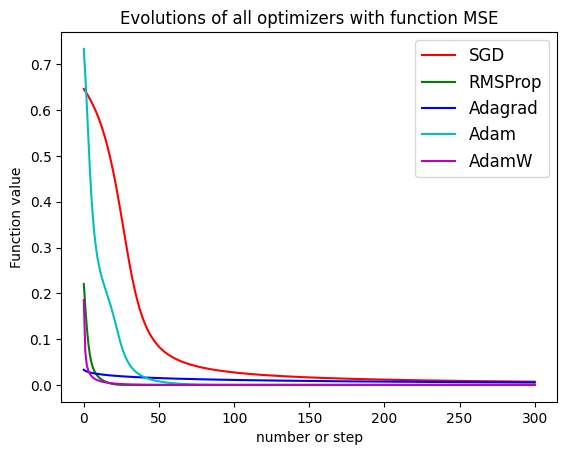

In [20]:
print("===--- Entraînement sur le jeu de données linéaire ---===")

nn_losses = []
l = [
    create_params(SGD, learning_rate=0.0001),
    create_params(RMSProp, learning_rate=0.001),
    create_params(Adagrad, learning_rate=0.001),
    create_params(Adam, learning_rate=0.001),
    create_params(AdamW, learning_rate=0.001),
]
print(l)
for params, opti in l:

    print(f"\n>>> Optimiseur: {opti.__class__.__name__}")
    epoch = 300
    params, losses = eval_nn_optim(x_linear, y_linear, optimizer=opti, epochs=epoch, params=params)
    print(f"Paramètres finaux (W1, b1, W2, b2) = {[p.data for p in params]}")
    print(f"Loss final = {losses[-1]:.4f}")
    nn_losses.append(losses)
plot_loss(nn_losses, "linear_nn_losses.png", epoch=300)


===--- Entraînement sur le jeu de données non-linéaire ---===
[((Tensor(data=-0.955945000492777, grad=0.0), Tensor(data=-0.34598177569938643, grad=0.0), Tensor(data=-0.4635959746460942, grad=0.0), Tensor(data=0.4814814737734622, grad=0.0)), <__main__.SGD object at 0x11ddfabf0>), ((Tensor(data=-1.5407970144446248, grad=0.0), Tensor(data=0.06326199420033171, grad=0.0), Tensor(data=0.1565065379653756, grad=0.0), Tensor(data=0.23218103620027578, grad=0.0)), <__main__.RMSProp object at 0x11ddfaf20>), ((Tensor(data=-0.5973160689653627, grad=0.0), Tensor(data=-0.237921729736007, grad=0.0), Tensor(data=-1.4240609089825316, grad=0.0), Tensor(data=-0.49331988336219407, grad=0.0)), <__main__.Adagrad object at 0x11da2e800>), ((Tensor(data=-0.5428614760167177, grad=0.0), Tensor(data=0.4160500462614255, grad=0.0), Tensor(data=-1.1561824318219127, grad=0.0), Tensor(data=0.7811981017099934, grad=0.0)), <__main__.Adam object at 0x11dd7c070>), ((Tensor(data=1.4944845444913688, grad=0.0), Tensor(data=-2

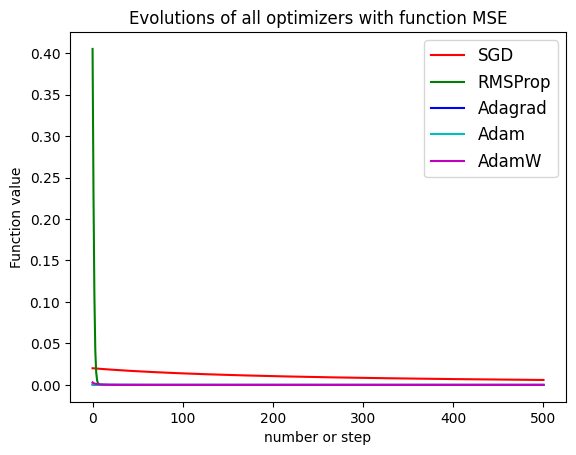

In [21]:
print("\n===--- Entraînement sur le jeu de données non-linéaire ---===")

nn_losses = []
l = [
    create_params(SGD, learning_rate=0.0001),
    create_params(RMSProp, learning_rate=0.001),
    create_params(Adagrad, learning_rate=0.001),
    create_params(Adam, learning_rate=0.001),
    create_params(AdamW, learning_rate=0.001),
]
print(l)
for params, opti in l:
    epoch = 500
    print(f"\n>>> Optimiseur: {opti.__class__.__name__}")
    params, losses = eval_nn_optim(x_linear, y_nonlinear, optimizer=opti, epochs=epoch, params=params)
    print(f"Paramètres finaux (W1, b1, W2, b2) = {[p.data for p in params]}")
    print(f"Loss final = {losses[-1]:.4f}")
    nn_losses.append(losses)
plot_loss(nn_losses, "nonlinear_nn_losses.png", epoch)

# Scheduler de Taux d’Apprentissage

## LRScheduler

Le `LRScheduler` ajuste le taux d’apprentissage en fonction des métriques observées pendant l’entraînement.

In [22]:
class LRScheduler:
    def __init__(self, optimizer, initial_lr):
        self.optimizer = optimizer
        optimizer.defaults["initial_lr"] = initial_lr

    def step(self, metric):
        pass

## LRSchedulerOnPlateau

Cette classe ajuste le taux d’apprentissage en fonction de l’absence d’amélioration
sur un certain nombre d’époques.

Nous évaluerons les schedulers de taux d’apprentissage, `LRScheduler` et
`LRSchedulerOnPlateau`, dans le cadre des deux fonctions mentionnées, à savoir
la minimisation des fonctions de perte et l’entraînement du réseau de neurones.
Cette évaluation permettra d’analyser leur impact sur la convergence et les performances du modèle.


In [23]:
class LRSchedulerOnPlateau(LRScheduler):
    def __init__(self, optimizer, initial_lr, patience=10, factor=0.1, min_lr=1e-6, mode='min', threshold=1e-4):
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.mode = mode
        self.threshold = threshold
        if not isinstance(optimizer, Optimizer):
            raise TypeError(f"{type(optimizer).__name__} is not an Optimizer")
        super(LRSchedulerOnPlateau, self).__init__(optimizer, initial_lr)

        self.counter = 0
        self.last_metric = inf if mode == "min" else -inf
        self.last_epoch = 0
        self.eps = 1e-8

    def step(self, metric):
        if self.mode == "min":
            rel_epsilon = 1.0 - self.threshold
            current = metric < self.last_metric - self.threshold
        else:
            rel_epsilon = self.threshold + 1.0
            current = metric > self.last_metric + self.threshold

        if current:
            self.last_metric = metric
            self.counter = 0
        else:
            self.counter += 1

        if self.counter > self.patience:
            old_lr = self.optimizer.defaults["lr"]
            new_lr = max(old_lr * self.factor, self.min_lr)

            if old_lr - new_lr > self.eps:
                print(f"{self.optimizer.__class__.__name__} Scheduler: Reached patience, new lr: {new_lr}")
                self.optimizer.defaults["lr"] = new_lr
            self.counter = 0

In [24]:
def eval_fn_with_scheduler(function, starting_point=4):
    sgd_tensor = Tensor(starting_point)
    sgd = SGD([sgd_tensor])
    sgd_scheduler = LRSchedulerOnPlateau(sgd, initial_lr=sgd.defaults["lr"], patience=50)

    rmsprop_tensor = Tensor(starting_point)
    rmsprop = RMSProp([rmsprop_tensor], learning_rate=0.1)
    rmsprop_scheduler = LRSchedulerOnPlateau(rmsprop, initial_lr=rmsprop.defaults["lr"], patience=50)

    adagrad_tensor = Tensor(starting_point)
    adagrad = Adagrad([adagrad_tensor], learning_rate=0.1)
    adagrad_scheduler = LRSchedulerOnPlateau(adagrad, initial_lr=adagrad.defaults["lr"], patience=50)

    adam_tensor = Tensor(starting_point)
    adam = Adam([adam_tensor], learning_rate=0.1)
    adam_scheduler = LRSchedulerOnPlateau(adam, initial_lr=adam.defaults["lr"], factor=0.1, patience=50)

    adamw_tensor = Tensor(starting_point)
    adamw = AdamW([adamw_tensor], learning_rate=0.1)
    adamw_scheduler = LRSchedulerOnPlateau(adamw, initial_lr=adamw.defaults["lr"], patience=50)

    tensors = [sgd_tensor, rmsprop_tensor, adagrad_tensor, adam_tensor, adamw_tensor]
    optims = [sgd, rmsprop, adagrad, adam, adamw]
    schedulers = [sgd_scheduler, rmsprop_scheduler, adagrad_scheduler, adam_scheduler, adamw_scheduler]

    traj = defaultdict(list)
    for step in range(500):
        for i, (optim, tensor, scheduler) in enumerate(zip(optims, tensors, schedulers)):
            loss = function(tensor)
            optim.zero_grad()
            loss.backward()
            optim.step()
            scheduler.step(loss.data)
            traj[i].append(tensor.data)
        print(f"step {step}:")
        for i in range(len(optims)):
            optim = optims[i]
            t = traj[i]
            print(f"    - {optim.__class__.__name__}:{f(t[-1]):.5f}")
    return traj, optims


def create_anim_with_scheduler(fn, name, starting_point=4):
    fn_def = '(x - 2)^2' if fn is f else '3x^2 - 2x'
    print(f"=== EVALUATING FUNCTION: {fn_def} ===")
    traj, optims = eval_fn_with_scheduler(fn, starting_point=starting_point)

    # Animation
    fig, ax = plt.subplots(figsize=(8, 6))
    x_vals = np.linspace(min(-2, starting_point - 2), max(starting_point + 2, 6), 500)
    y_vals = [(Tensor(x).data, fn(Tensor(x)).data) for x in x_vals]
    x_vals, y_vals = zip(*y_vals)

    ax.plot(x_vals, y_vals, label=f"f(x) = {fn_def}", color="blue", linewidth=2)
    points = []
    for optim, color in zip(optims, ['ro', 'bo', 'go', 'co', 'mo']):
        p, = ax.plot([], [], color, label=optim.__class__.__name__, markersize=8)
        points.append(p)

    ax.set_xlim(np.min(x_vals) - 1, np.max(x_vals) + 1)
    ax.set_ylim(np.min(y_vals) - 5, np.max(y_vals) + 1)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    title = ax.set_title(f"{fn_def} with x_start={starting_point}", fontsize=14)

    def update(frame):
        for i in range(len(points)):
            p = points[i]
            p.set_data([traj[i][frame]], [fn(Tensor(traj[i][frame])).data])
        title.set_text(f"Step: {frame}")
        return *points, title

    ani = FuncAnimation(fig, update, frames=500, interval=200, blit=True)
    ani.save(name)

    # Courbe
    plt.figure()
    x = np.linspace(0, 500, 500)

    plt.plot(x, [fn(traj[0][i]) for i in range(len(traj[0]))], "r-", label="SGD")
    plt.plot(x, [fn(traj[1][i]) for i in range(len(traj[1]))], "g-", label="RMSProp")
    plt.plot(x, [fn(traj[2][i]) for i in range(len(traj[2]))], "b-", label="Adagrad")
    plt.plot(x, [fn(traj[3][i]) for i in range(len(traj[3]))], "c-", label="Adam")
    plt.plot(x, [fn(traj[4][i]) for i in range(len(traj[4]))], "m-", label="AdamW")

    plt.xlabel("number or step")
    plt.ylabel("Function value")
    plt.title(f"Evolutions of all optimizers with function {fn_def} and x_start={starting_point}")
    plt.legend(fontsize=12)
    plt.savefig(name.split(".")[0] + ".png")


def eval_optim_with_scheduler(starting_point=4):
    datanow = datetime.datetime.now().strftime('%y-%m-%d_%H-%M-%S')

    create_anim_with_scheduler(f, f"scheduler_convexe_{starting_point}.gif", starting_point=starting_point)
    create_anim_with_scheduler(f_nonconvexe, f"scheduler_nonconvexe_{starting_point}.gif",
                               starting_point=starting_point)


MovieWriter ffmpeg unavailable; using Pillow instead.


=== EVALUATING FUNCTION: (x - 2)^2 ===
step 0:
    - SGD:245.86240
    - RMSProp:245.98071
    - Adagrad:252.81000
    - Adam:252.81000
    - AdamW:252.23792
step 1:
    - SGD:236.12625
    - RMSProp:238.90457
    - Adagrad:250.57343
    - Adam:248.55536
    - AdamW:247.42538
step 2:
    - SGD:226.77565
    - RMSProp:233.09271
    - Adagrad:248.75814
    - Adam:243.64656
    - AdamW:241.97630
step 3:
    - SGD:217.79533
    - RMSProp:228.01582
    - Adagrad:247.19369
    - Adam:238.31010
    - AdamW:236.11930
step 4:
    - SGD:209.17064
    - RMSProp:223.42920
    - Adagrad:245.80029
    - Adam:232.69470
    - AdamW:230.00433
step 5:
    - SGD:200.88748
    - RMSProp:219.19684
    - Adagrad:244.53310
    - Adam:226.90582
    - AdamW:223.73761
step 6:
    - SGD:192.93234
    - RMSProp:215.23436
    - Adagrad:243.36396
    - Adam:221.02144
    - AdamW:217.39747
step 7:
    - SGD:185.29222
    - RMSProp:211.48532
    - Adagrad:242.27383
    - Adam:215.10060
    - AdamW:211.04306
step 8:
 


KeyboardInterrupt



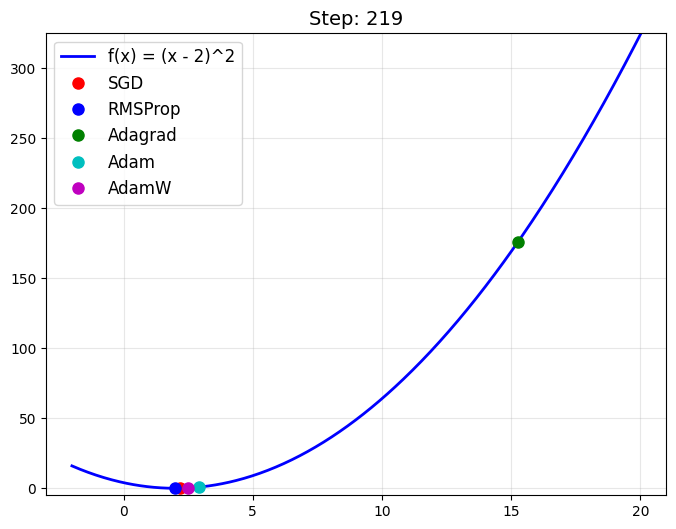

In [87]:
eval_optim_with_scheduler(18)


Voici une animation qui montre la minimisation de la fonction convexe par nos différents optimizeurs:
![gif](scheduler_convexe_18.gif "gif")

Et la même avec la fonction "non convexe":
![gif](scheduler_nonconvexe_18.gif "gif")

In [25]:
def eval_nn_optim(x_data, y_data, optimizer, params, epochs):
    W1, b1, W2, b2 = params
    losses = []
    scheduler = LRSchedulerOnPlateau(optimizer=optimizer, initial_lr=optimizer.defaults['lr'], patience=50)
    for epoch in range(epochs):
        epoch_loss = []
        for x, y in zip(x_data, y_data):
            x_t = Tensor(x)
            y_t = Tensor(y)
            y_pred = func_nn(x_t, W1, b1, W2, b2)
            loss = mse(y_t, y_pred)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step(loss.data)
            epoch_loss.append(loss.data)

        epoch_loss = np.mean(epoch_loss)
        losses.append(epoch_loss)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss:.4f}")
    return (W1, b1, W2, b2), losses

## Entraînement des réseaux avec le scheduler

===--- Entraînement sur le jeu de données linéaire ---===
[((Tensor(data=1.8495912466796365, grad=0.0), Tensor(data=-0.21416665620008424, grad=0.0), Tensor(data=-0.4990166379941829, grad=0.0), Tensor(data=0.02135122384354861, grad=0.0)), <__main__.SGD object at 0x11f32d120>), ((Tensor(data=-0.9191134448699437, grad=0.0), Tensor(data=0.19275384906521617, grad=0.0), Tensor(data=-0.36505521654625767, grad=0.0), Tensor(data=-1.7913275480411837, grad=0.0)), <__main__.RMSProp object at 0x11f39a3b0>), ((Tensor(data=-0.05858655113386085, grad=0.0), Tensor(data=-0.31754309393019925, grad=0.0), Tensor(data=-1.6324233020679833, grad=0.0), Tensor(data=-0.06713415461452177, grad=0.0)), <__main__.Adagrad object at 0x11e9082e0>), ((Tensor(data=1.4893559620744803, grad=0.0), Tensor(data=0.5213037482757137, grad=0.0), Tensor(data=0.6119271927311578, grad=0.0), Tensor(data=-1.3414967255830426, grad=0.0)), <__main__.Adam object at 0x11e909690>), ((Tensor(data=0.4768983689222224, grad=0.0), Tensor(data=0.

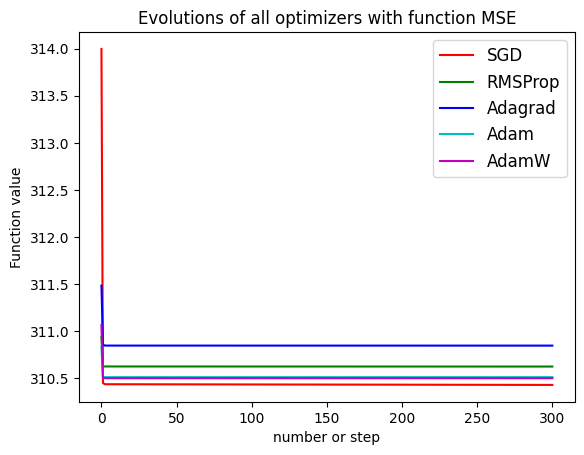

In [89]:
print("===--- Entraînement sur le jeu de données linéaire ---===")

nn_losses = []
l = [
    create_params(SGD, learning_rate=0.1),
    create_params(RMSProp, learning_rate=0.1),
    create_params(Adagrad, learning_rate=0.1),
    create_params(Adam, learning_rate=0.1),
    create_params(AdamW, learning_rate=0.1),
]
print(l)
for params, opti in l:

    print(f"\n>>> Optimiseur: {opti.__class__.__name__}")
    epoch = 300
    params, losses = eval_nn_optim(x_linear, y_linear, optimizer=opti, epochs=epoch, params=params)
    print(f"Paramètres finaux (W1, b1, W2, b2) = {[p.data for p in params]}")
    print(f"Loss final = {losses[-1]:.4f}")
    nn_losses.append(losses)
plot_loss(nn_losses, "linear_nn_losses.png", epoch=300)

===--- Entraînement sur le jeu de données linéaire ---===
[((Tensor(data=-1.3597807255038137, grad=0.0), Tensor(data=-0.04140081155796743, grad=0.0), Tensor(data=-0.757870860425166, grad=0.0), Tensor(data=-0.05008409428482209, grad=0.0)), <__main__.SGD object at 0x1200711b0>), ((Tensor(data=-0.8974009269018305, grad=0.0), Tensor(data=1.3124703671409963, grad=0.0), Tensor(data=-0.8589723884443423, grad=0.0), Tensor(data=-0.898942156465536, grad=0.0)), <__main__.RMSProp object at 0x120070490>), ((Tensor(data=0.07458640654355353, grad=0.0), Tensor(data=-1.0770990694039948, grad=0.0), Tensor(data=-0.4246633024328657, grad=0.0), Tensor(data=-0.8299645975379619, grad=0.0)), <__main__.Adagrad object at 0x120072230>), ((Tensor(data=1.4111720638896117, grad=0.0), Tensor(data=0.7858038268311726, grad=0.0), Tensor(data=-0.057469518465394644, grad=0.0), Tensor(data=-0.39121705217401626, grad=0.0)), <__main__.Adam object at 0x120070550>), ((Tensor(data=0.9409176145751134, grad=0.0), Tensor(data=0.4

/var/folders/nr/6q8rzthj5bn1rxt54nzp01_w0000gn/T/ipykernel_13161/4143868844.py:2: RuntimeWarning: overflow encountered in exp
  sig = 1 / (1 + np.exp(-dual_number.data))


Epoch 100/500 - Loss: 1126.4174
Epoch 200/500 - Loss: 1126.4174
Epoch 300/500 - Loss: 1126.4174
Epoch 400/500 - Loss: 1126.4174
Paramètres finaux (W1, b1, W2, b2) = [13.750996731630833, 0.2043070545660864, -10.016880812649525, 9.39598974968375]
Loss final = 1126.4174

>>> Optimiseur: AdamW
Epoch 0/500 - Loss: 1130.4053
AdamW Scheduler: Reached patience, new lr: 0.099
AdamW Scheduler: Reached patience, new lr: 0.0099
AdamW Scheduler: Reached patience, new lr: 0.0009900000000000002
AdamW Scheduler: Reached patience, new lr: 9.900000000000002e-05
AdamW Scheduler: Reached patience, new lr: 9.900000000000003e-06
AdamW Scheduler: Reached patience, new lr: 1e-06
Epoch 100/500 - Loss: 1126.3470
Epoch 200/500 - Loss: 1126.3470
Epoch 300/500 - Loss: 1126.3470
Epoch 400/500 - Loss: 1126.3469
Paramètres finaux (W1, b1, W2, b2) = [2.3972268576887554, 2.9334675854819934, -2.9767118710440372, 5.243808830508296]
Loss final = 1126.3469


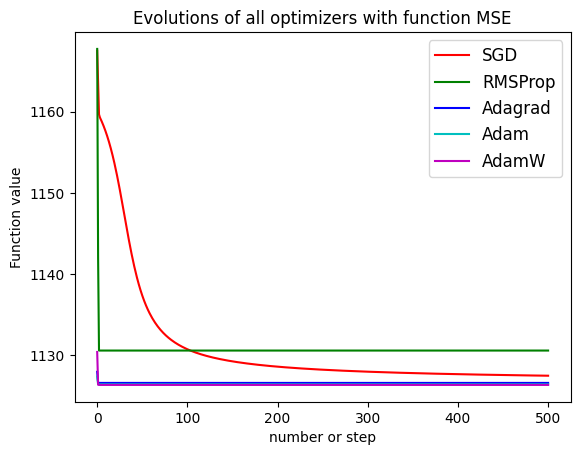

In [90]:
print("===--- Entraînement sur le jeu de données linéaire ---===")

nn_losses = []
l = [
    create_params(SGD, learning_rate=0.001),
    create_params(RMSProp, learning_rate=0.99),
    create_params(Adagrad, learning_rate=0.99),
    create_params(Adam, learning_rate=0.99),
    create_params(AdamW, learning_rate=0.99),
]
print(l)
for params, opti in l:

    print(f"\n>>> Optimiseur: {opti.__class__.__name__}")
    epoch = 500
    params, losses = eval_nn_optim(x_linear, y_nonlinear, optimizer=opti, epochs=epoch, params=params)
    print(f"Paramètres finaux (W1, b1, W2, b2) = {[p.data for p in params]}")
    print(f"Loss final = {losses[-1]:.4f}")
    nn_losses.append(losses)
plot_loss(nn_losses, "linear_nn_losses.png", epoch=500)

# TP 5

In [ ]:
import numpy as np
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        layer1 = [Tensor(np.random.randn()) for i in range(0, input_size)]
        layerh = [Tensor(np.random.randn()) for i in range(0, hidden_size)]
        layer2 = [Tensor(np.random.randn()) for i in range(0, output_Size)]

        bias1 = Tensor(np.random.randn() for i in range(0, hidden_size))

        
        
    def forward(self, x, training=True):
        pass
        
        
    def backward(self, x, y, y_hat):
        pass
        
    def update_parameters(self, optimizer):
        pass

In [27]:
class DropoutNN:
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        self.W1 = Tensor(np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size))
        self.b1 = Tensor(np.zeros(hidden_size))
        self.W2 = Tensor(np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size))
        self.b1 = Tensor(np.zeros(hidden_size))
        
    def forward(self, x, training=True): 
        self.x = Tensor()
        self.h1 = (self.x * self.W1 + self.b1).relu()

        if training:
            self.mask = Tensor(np.random.binomial(1, 1 - self.dropout_prob, size=self.h1.data.shape))
            self.h1 = self.h1 * self.mask

        self.y_hat = self.h1 * self.W2 + self.b2
        return self.y_hat

    def backward(self, x, y, y_hat):
    # Impl ́ementation de la r ́etropropagation pass
        y = Tensor(y)
        loss = ((y_hat - y) ** 2).sum()
        loss.backward()
        return loss

    def update_parameters(self, optimizer):
    # Mise `a jour des param`etres avec l’optimiseur pass
        self.W1.data -= learning_rate * self.W1.grad
        self.b1.data -= learning_rate * self.b1.grad
        self.W2.data -= learning_rate * self.W2.grad
        self.b2.data -= learning_rate * self.b2.grad

    def train_step(self, x, y, learning_rate):
        y_hat = self.forward(x, training=True)
        loss = self.backward(y, y_hat)
        self.update_parameters(learning_rate)
        return loss

In [28]:
class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.Wx = Tensor(np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size))
        self.Wh = Tensor(np.random.randn(hidden_size, hidden_size) * np.sqrt(2. / hidden_size))
        self.Wy = Tensor(np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size))
        self.bh = Tensor(np.zeros(hidden_size))
        self.by = Tensor(np.zeros(output_size))

    def forward(self, x):
        T = len(x)
        self.h = [Tensor(np.zeros(self.Wh.data.shape[0])) for _ in range(T)]
        self.y = [None] * T

        for t in range(T):
            self.h[t] = (x[t] * self.Wx + self.h[t - 1] * self.Wh + self.bh).relu() if t > 0 else (x[t] * self.Wx + self.bh).relu()
            self.y[t] = self.h[t] * self.Wy + self.by
        return self.y, self.h

    def backward(self, x, y, y_hat):
        y = [Tensor(yi) for yi in y]
        loss = sum(((y_hat[t] - y[t]) ** 2).sum() for t in range(len(y)))
        loss.backward()
        return loss

    def update_parameters(self, learning_rate):
        self.Wx.data -= learning_rate * self.Wx.grad
        self.Wh.data -= learning_rate * self.Wh.grad
        self.Wy.data -= learning_rate * self.Wy.grad
        self.bh.data -= learning_rate * self.bh.grad
        self.by.data -= learning_rate * self.by.grad

    def train_step(self, x, y, learning_rate):
        y_hat, _ = self.forward(x)
        loss = self.backward(x, y, y_hat)
        self.update_parameters(learning_rate)
        return loss

# Example usage
if __name__ == "__main__":
    # Sample sequential data
    np.random.seed(42)
    x = [Tensor(xi) for xi in np.random.randn(10, 8)]  # Sequence length 10, feature size 8
    y = [Tensor(yi) for yi in np.random.randn(10, 4)]  # Sequence length 10, output size 4

    model = SimpleRNN(input_size=8, hidden_size=16, output_size=4)
